## A

In [ ]:
# ==========================================
# RICE IMAGE DATASET - WGET İLE İNDİRME VE CNN CLASSIFIER
# 5-Class Rice Variety Classification
# ==========================================

# # Rice Image Dataset Sınıflandırması
#
# Bu notebook, Rice Image Dataset'i wget ile indirir ve sıfırdan özel CNN modeli tasarlar.
# Dataset: 75,000 RGB görüntü, 5 pirinç türü (Arborio, Basmati, Ipsala, Jasmine, Karacadag)


# ## 1. Veri Setini İndirme (Wget ile Direkt İndirme)

# %%
import os
import subprocess
import zipfile
import glob
from pathlib import Path

def download_dataset_direct(download_url, dest_folder, zip_filename):
    """
    Belirtilen URL'den wget ile veri seti zip dosyasını indirir.
    İndirilen dosya, dest_folder içine zip_filename olarak kaydedilir.
    """
    if not os.path.exists(dest_folder):
        os.makedirs(dest_folder)

    full_zip_path = os.path.join(dest_folder, zip_filename)

    print(f"\n{zip_filename} indiriliyor...\nURL: {download_url}")
    print("Bu işlem birkaç dakika sürebilir (Dataset ~1.2 GB)...")

    try:
        cmd = ["wget", "-O", full_zip_path, download_url]
        subprocess.run(cmd, check=True)
        print(f"{zip_filename} başarıyla indirildi: {full_zip_path}")
        return True
    except Exception as e:
        print(f"İndirme hatası ({zip_filename}): {e}")
        return False

def extract_dataset(dest_folder):
    """İndirilen zip dosyasını açar"""
    try:
        zip_files = glob.glob(os.path.join(dest_folder, "*.zip"))
        if not zip_files:
            print(f"Uyarı: {dest_folder} klasöründe zip dosyası bulunamadı")
            return False

        for zip_file in zip_files:
            print(f"Zip dosyası açılıyor: {zip_file}")
            with zipfile.ZipFile(zip_file, 'r') as zip_ref:
                zip_ref.extractall(dest_folder)

            # Zip dosyasını sil (disk alanı tasarrufu)
            os.remove(zip_file)
            print(f"Zip dosyası silindi: {zip_file}")

        print(f"Dataset başarıyla açıldı: {dest_folder}")
        return True
    except Exception as e:
        print(f"Zip açma hatası: {e}")
        return False

# Ana klasörü oluştur
dataset_folder = "rice_dataset"
if not os.path.exists(dataset_folder):
    os.makedirs(dataset_folder)
    print(f"Klasör oluşturuldu: {dataset_folder}")

# Rice Image Dataset bilgileri
rice_dataset_info = {
    "name": "rice-image-dataset",
    "download_url": "https://www.kaggle.com/api/v1/datasets/download/muratkokludataset/rice-image-dataset",
    "folder": dataset_folder,
    "zip_filename": "rice-image-dataset.zip"
}

# Dataset zaten var mı kontrol et
rice_dataset_path = os.path.join(dataset_folder, "Rice_Image_Dataset")
if os.path.exists(rice_dataset_path):
    print("\n" + "="*60)
    print("Dataset zaten mevcut, indirme atlanıyor...")
    print("="*60)
else:
    # İndirme işlemi
    print("\n" + "="*60)
    print("RICE IMAGE DATASET İNDİRİLİYOR")
    print("="*60)

    download_success = download_dataset_direct(
        rice_dataset_info["download_url"],
        rice_dataset_info["folder"],
        rice_dataset_info["zip_filename"]
    )

    if download_success:
        # Zip dosyasını aç
        print("\n" + "="*60)
        print("ZIP DOSYASI AÇILIYOR")
        print("="*60)
        extract_dataset(rice_dataset_info["folder"])
    else:
        print("\n❌ İndirme başarısız!")
        print("\nMANUEL İNDİRME TALİMATLARI:")
        print("1. https://www.kaggle.com/datasets/muratkokludataset/rice-image-dataset")
        print("2. 'Download' butonuna tıklayın")
        print(f"3. İndirilen zip'i {dataset_folder}/ klasörüne koyun")
        print("4. Bu notebook'u tekrar çalıştırın")

# Dataset yapısını kontrol et ve göster
if os.path.exists(rice_dataset_path):
    print("\n" + "="*60)
    print("DATASET YAPISI")
    print("="*60)

    rice_varieties = [d for d in os.listdir(rice_dataset_path)
                     if os.path.isdir(os.path.join(rice_dataset_path, d))]

    total_images = 0
    for variety in rice_varieties:
        variety_path = os.path.join(rice_dataset_path, variety)
        count = len([f for f in os.listdir(variety_path)
                    if f.endswith(('.jpg', '.png', '.jpeg'))])
        print(f"  {variety}: {count:,} görüntü")
        total_images += count

    print(f"\nToplam: {total_images:,} görüntü")
    print("="*60)
    print("\n✅ Dataset başarıyla hazır!")

Klasör oluşturuldu: rice_dataset

RICE IMAGE DATASET İNDİRİLİYOR

rice-image-dataset.zip indiriliyor...
URL: https://www.kaggle.com/api/v1/datasets/download/muratkokludataset/rice-image-dataset
Bu işlem birkaç dakika sürebilir (Dataset ~1.2 GB)...
rice-image-dataset.zip başarıyla indirildi: rice_dataset/rice-image-dataset.zip

ZIP DOSYASI AÇILIYOR
Zip dosyası açılıyor: rice_dataset/rice-image-dataset.zip
Zip dosyası silindi: rice_dataset/rice-image-dataset.zip
Dataset başarıyla açıldı: rice_dataset

DATASET YAPISI
  Arborio: 15,000 görüntü
  Jasmine: 15,000 görüntü
  Ipsala: 15,000 görüntü
  Basmati: 15,000 görüntü
  Karacadag: 15,000 görüntü

Toplam: 75,000 görüntü

✅ Dataset başarıyla hazır!


In [ ]:

# ## 2. Kütüphaneler ve Ortam Ayarları

# %%
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import cv2

# Reproducibility için seed ayarla
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

# Dataset path
DATASET_PATH = 'rice_dataset/Rice_Image_Dataset'
IMG_SIZE = 224  # 128x128 veya 224x224
BATCH_SIZE = 256
NUM_CLASSES = 5


TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Dataset Dağılımı:
Arborio: 15,000 görüntü
Basmati: 15,000 görüntü
Ipsala: 15,000 görüntü
Jasmine: 15,000 görüntü
Karacadag: 15,000 görüntü


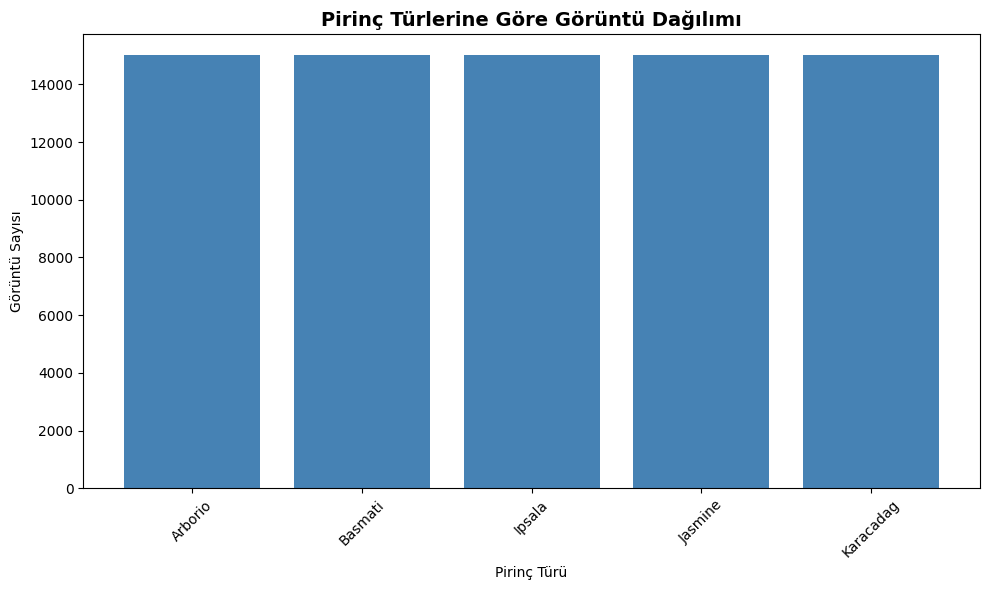

In [ ]:

# ## 3. Veri Ön İşleme ve Keşifsel Analiz

# %%
# Dataset yapısını incele
rice_varieties = ['Arborio', 'Basmati', 'Ipsala', 'Jasmine', 'Karacadag']

# Görüntü sayılarını say
image_counts = {}
for variety in rice_varieties:
    variety_path = os.path.join(DATASET_PATH, variety)
    if os.path.exists(variety_path):
        count = len([f for f in os.listdir(variety_path) if f.endswith(('.jpg', '.png'))])
        image_counts[variety] = count

print("Dataset Dağılımı:")
for variety, count in image_counts.items():
    print(f"{variety}: {count:,} görüntü")

# Dağılımı görselleştir
plt.figure(figsize=(10, 6))
plt.bar(image_counts.keys(), image_counts.values(), color='steelblue')
plt.title('Pirinç Türlerine Göre Görüntü Dağılımı', fontsize=14, fontweight='bold')
plt.xlabel('Pirinç Türü')
plt.ylabel('Görüntü Sayısı')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


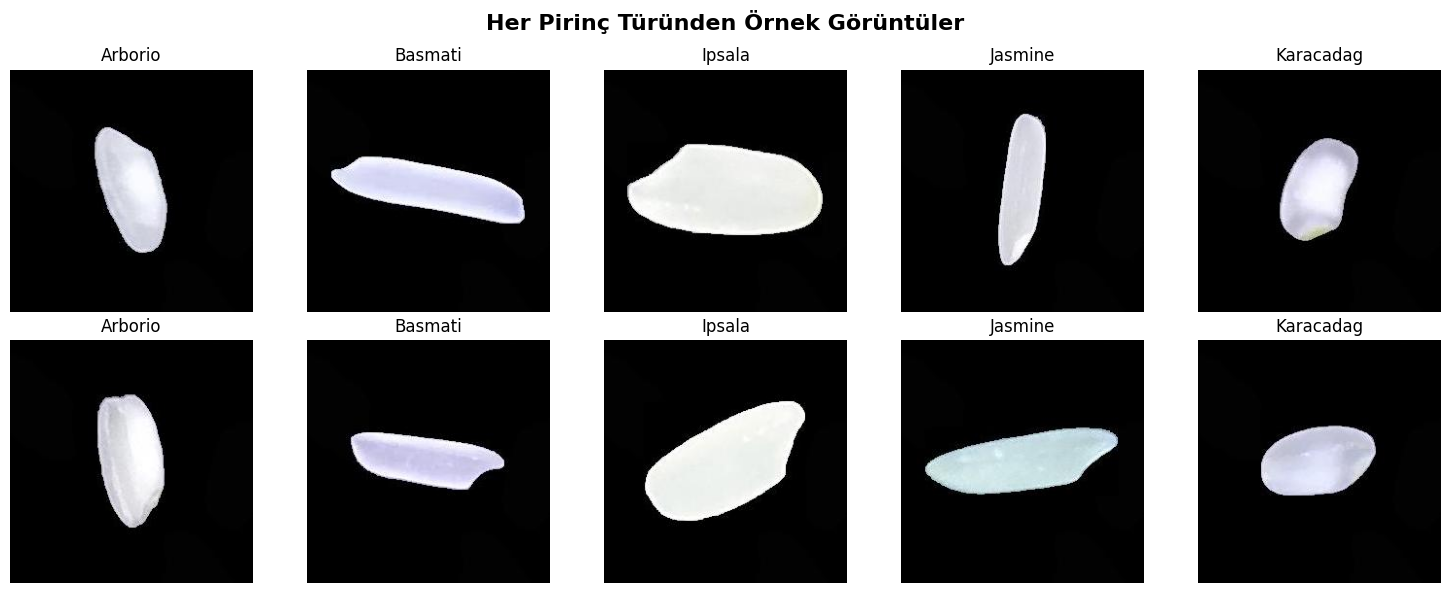

In [ ]:
# ## 4. Örnek Görüntüleri Görselleştirme

# %%
# Her sınıftan örnek görüntüler göster
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Her Pirinç Türünden Örnek Görüntüler', fontsize=16, fontweight='bold')

for idx, variety in enumerate(rice_varieties):
    variety_path = os.path.join(DATASET_PATH, variety)
    images = [f for f in os.listdir(variety_path) if f.endswith(('.jpg', '.png'))][:2]

    for i, img_name in enumerate(images):
        img_path = os.path.join(variety_path, img_name)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        axes[i, idx].imshow(img)
        axes[i, idx].set_title(variety)
        axes[i, idx].axis('off')

plt.tight_layout()
plt.show()


In [ ]:

# ## 5. Data Augmentation ve Generator Oluşturma

# %%
# Training için data augmentation (literatür önerileri)
train_datagen = ImageDataGenerator(
    rescale=1./255,                  # [0,1] normalization
    rotation_range=30,               # ±30° rotation
    horizontal_flip=True,            # Horizontal flip
    vertical_flip=True,              # Vertical flip
    width_shift_range=0.1,           # ±10% translation
    height_shift_range=0.1,
    zoom_range=0.3,                  # 0.7x-1.3x zoom
    brightness_range=[0.8, 1.2],     # ±20% brightness
    shear_range=0.15,                # Shearing
    fill_mode='nearest',
    validation_split=0.2             # 80% train, 20% validation
)

# Test için sadece rescaling (NO augmentation)
test_datagen = ImageDataGenerator(rescale=1./255)

# Training generator
train_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

# Validation generator
validation_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

# Class indices
class_indices = train_generator.class_indices
print("\nClass mapping:")
for name, idx in class_indices.items():
    print(f"  {name}: {idx}")


Found 60000 images belonging to 5 classes.
Found 15000 images belonging to 5 classes.

Class mapping:
  Arborio: 0
  Basmati: 1
  Ipsala: 2
  Jasmine: 3
  Karacadag: 4


In [ ]:

# ## 6. Custom CNN Model Mimarisi Tasarımı
#
# **Literatür tabanlı optimal konfigürasyon:**
# - 3 konvolüsyonel blok (32→64→128 filtre progression)
# - 3×3 kernel size (VGG prensibi)
# - MaxPooling 2×2 her blok sonunda
# - Batch Normalization (training stability)
# - L2 regularization (overfitting prevention)
# - Dropout (0.2 conv layers, 0.5 dense layers)

# %%
def create_custom_rice_cnn(input_shape=(256, 256, 3), num_classes=5):
    """
    Pirinç sınıflandırması için optimize edilmiş custom CNN
    Literatür best practices ile tasarlanmıştır
    """
    model = keras.Sequential([
        # BLOCK 1: 32 filters
        layers.Conv2D(32, (3, 3), padding='same',
                     kernel_regularizer=regularizers.l2(0.0001),
                     input_shape=input_shape),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(32, (3, 3), padding='same',
                     kernel_regularizer=regularizers.l2(0.0001)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.SpatialDropout2D(0.2),

        # BLOCK 2: 64 filters
        layers.Conv2D(64, (3, 3), padding='same',
                     kernel_regularizer=regularizers.l2(0.0001)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(64, (3, 3), padding='same',
                     kernel_regularizer=regularizers.l2(0.0001)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.SpatialDropout2D(0.2),

        # BLOCK 3: 128 filters
        layers.Conv2D(128, (3, 3), padding='same',
                     kernel_regularizer=regularizers.l2(0.0001)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(128, (3, 3), padding='same',
                     kernel_regularizer=regularizers.l2(0.0001)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.SpatialDropout2D(0.25),

        # DENSE LAYERS
        layers.Flatten(),
        layers.Dense(512, kernel_regularizer=regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.5),

        layers.Dense(256, kernel_regularizer=regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.5),

        # OUTPUT LAYER
        layers.Dense(num_classes, activation='softmax')
    ])

    return model

# Model oluştur
model = create_custom_rice_cnn(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES)

# Model summary
model.summary()

# Model parametre sayısı
total_params = model.count_params()
print(f"\nToplam parametre sayısı: {total_params:,}")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d               │ (None, 112, 112, 32)   │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_1             │ (None, 56, 56, 64)     │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 51,805,221 (197.62 MB)

 Trainable params: 51,802,789 (197.61 MB)

 Non-trainable params: 2,432 (9.50 KB)


Toplam parametre sayısı: 51,805,221


visualkeras kütüphanesi yükleniyor...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 24.0 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/visualkeras/layered.py:86: UserWarning: The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.
  warnings.warn("The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.")


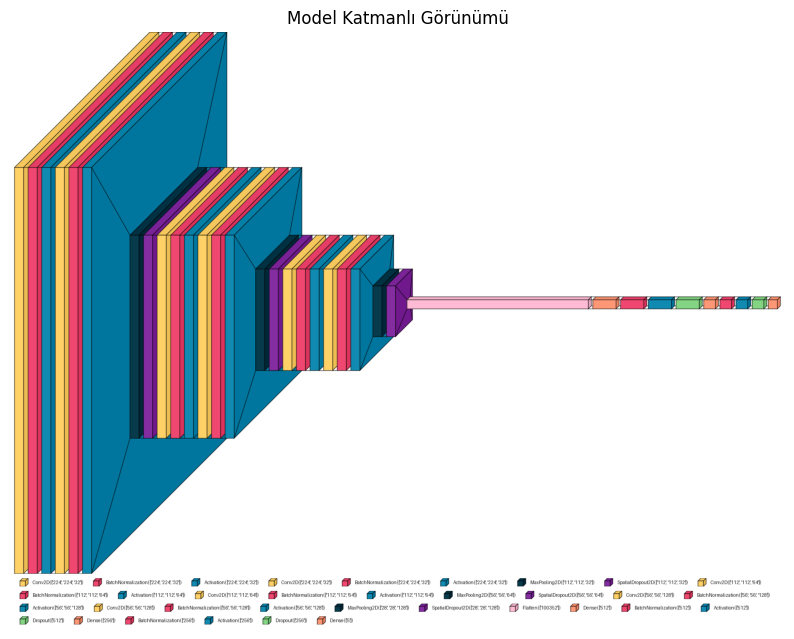

In [ ]:

# ## 7. Model Mimarisini Görselleştirme
# visualkeras kütüphanesini yükleme ve import etme
try:
    import visualkeras
except ImportError:
    print("visualkeras kütüphanesi yükleniyor...")
    !pip install visualkeras
    import visualkeras

# %%
# Katmanlı Görünüm (Layered View)
try:
    img = visualkeras.layered_view(model, legend=True, show_dimension=True)

    # Matplotlib kullanarak resmi görüntüleme:
    plt.figure(figsize=(10, 10))
    plt.imshow(img)
    plt.axis('off')
    plt.title("Model Katmanlı Görünümü")
    plt.show()
except Exception as e:
    print(f"Visualkeras ile görselleştirme sırasında hata: {e}")


In [ ]:

# ## 8. Model Derleme (Compilation)
#
# **Optimizer:** Adam (lr=0.0015) - Rice classification'da %98 accuracy achieve etmiştir
# **Loss:** Categorical Crossentropy - Multi-class classification için standard

# %%
# Model compile
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0015),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model başarıyla derlendi!")


Model başarıyla derlendi!


In [ ]:

# ## 9. Callbacks Tanımlama (Overfitting Prevention)

# %%
# Callbacks - Best practices
callbacks = [
    # Early Stopping: Validation loss plateau yaptığında dur
    EarlyStopping(
        monitor='val_loss',
        patience=5,                    # 15 epoch bekle
        min_delta=0.001,                # Minimum improvement threshold
        restore_best_weights=True,      # Best model'e geri dön
        verbose=1
    ),

    # Model Checkpoint: Best model'i kaydet
    ModelCheckpoint(
        filepath='best_rice_model.keras',
        monitor='val_loss',
        mode='min',
        save_best_only=True,
        verbose=1
    ),

    # Learning Rate Reduction: Plateau'da LR azalt
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,                     # LR'yi yarıya düşür
        patience=5,                     # 5 epoch bekle
        min_lr=1e-7,
        verbose=1
    )
]


In [ ]:
# ## 10. Model Eğitimi (Training)

# %%
# Training başlat
EPOCHS = 15  # Early stopping ile otomatik duracak

print("Model eğitimi başlıyor...")
print(f"Training samples: {train_generator.samples}")
print(f"Validation samples: {validation_generator.samples}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Steps per epoch: {train_generator.samples // BATCH_SIZE}")
print(f"Validation steps: {validation_generator.samples // BATCH_SIZE}")

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=validation_generator,
    callbacks=callbacks,
    verbose=1
)

print("\n✓ Model eğitimi tamamlandı!")

Model eğitimi başlıyor...
Training samples: 60000
Validation samples: 15000
Batch size: 256
Steps per epoch: 234
Validation steps: 58
Epoch 1/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6910 - loss: 2.9239
Epoch 1: val_loss improved from inf to 4.12223, saving model to best_rice_model.keras
235/235 ━━━━━━━━━━━━━━━━━━━━ 1005s 4s/step - accuracy: 0.6915 - loss: 2.9198 - val_accuracy: 0.2000 - val_loss: 4.1222 - learning_rate: 0.0015
Epoch 2/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9007 - loss: 0.8286
Epoch 2: val_loss improved from 4.12223 to 1.28990, saving model to best_rice_model.keras
235/235 ━━━━━━━━━━━━━━━━━━━━ 897s 4s/step - accuracy: 0.9007 - loss: 0.8284 - val_accuracy: 0.6486 - val_loss: 1.2899 - learning_rate: 0.0015
Epoch 3/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9234 - loss: 0.6526
Epoch 3: val_loss improved from 1.28990 to 0.69923, saving model to best_rice_model.keras
235/235 ━━━━━━━━━━━━━━━━━━━━ 895s 4s/step - accuracy: 0.9234

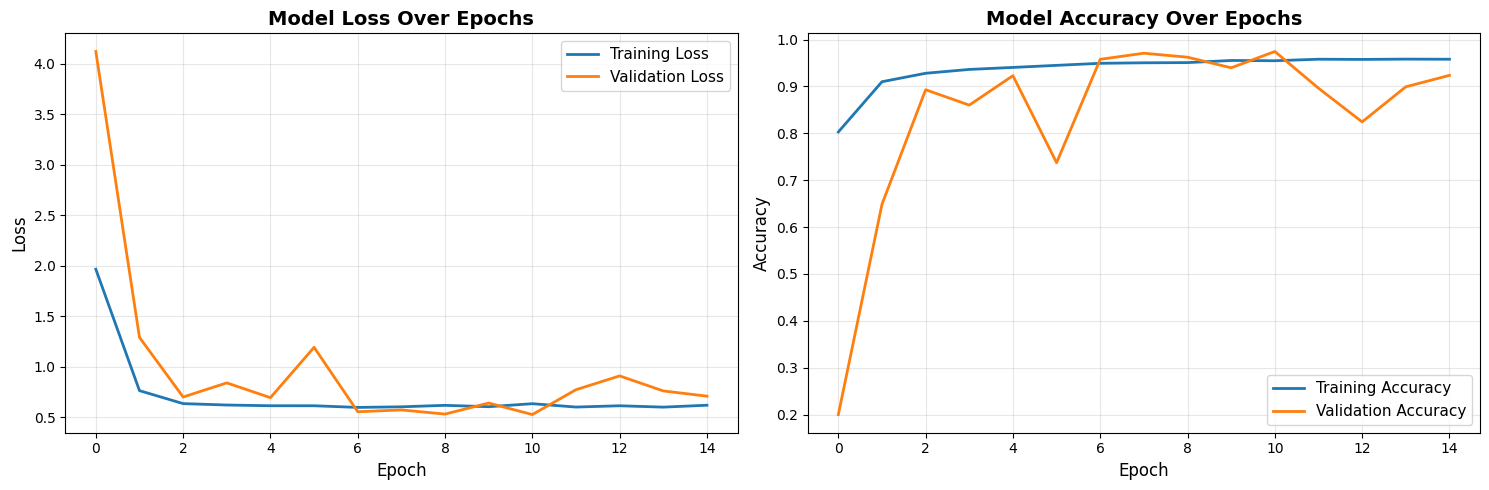


TRAINING SUMMARY
Final Training Loss:     0.6179
Final Validation Loss:   0.7079
Final Training Accuracy: 0.9580 (95.80%)
Final Val Accuracy:      0.9236 (92.36%)
Val/Train Loss Ratio:    1.1456

✓  Model iyi performans gösteriyor!


In [ ]:
# ## 11. Training Sonuçlarını Görselleştirme

# %%
# Training history plot
def plot_training_history(history):
    """Training ve validation metrics'i görselleştir"""
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Loss plot
    axes[0].plot(history.history['loss'], label='Training Loss', linewidth=2)
    axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    axes[0].set_title('Model Loss Over Epochs', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].legend(fontsize=11)
    axes[0].grid(alpha=0.3)

    # Accuracy plot
    axes[1].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
    axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
    axes[1].set_title('Model Accuracy Over Epochs', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Accuracy', fontsize=12)
    axes[1].legend(fontsize=11)
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Overfitting detection
    final_train_loss = history.history['loss'][-1]
    final_val_loss = history.history['val_loss'][-1]
    overfitting_ratio = final_val_loss / final_train_loss

    final_train_acc = history.history['accuracy'][-1]
    final_val_acc = history.history['val_accuracy'][-1]

    print("\n" + "="*60)
    print("TRAINING SUMMARY")
    print("="*60)
    print(f"Final Training Loss:     {final_train_loss:.4f}")
    print(f"Final Validation Loss:   {final_val_loss:.4f}")
    print(f"Final Training Accuracy: {final_train_acc:.4f} ({final_train_acc*100:.2f}%)")
    print(f"Final Val Accuracy:      {final_val_acc:.4f} ({final_val_acc*100:.2f}%)")
    print(f"Val/Train Loss Ratio:    {overfitting_ratio:.4f}")

    if overfitting_ratio > 1.2:
        print("\n⚠️  OVERFITTING TESPİT EDİLDİ!")
        print("   Daha fazla regularization veya data augmentation deneyin.")
    elif final_val_acc < 0.85:
        print("\n⚠️  UNDERFITTING OLABİLİR")
        print("   Model kapasitesini artırın veya daha uzun train edin.")
    else:
        print("\n✓  Model iyi performans gösteriyor!")
    print("="*60)

plot_training_history(history)

## B

In [ ]:
# ==========================================
# RICE IMAGE DATASET - WGET İLE İNDİRME VE CNN CLASSIFIER
# 5-Class Rice Variety Classification
# ==========================================


# # Rice Image Dataset Sınıflandırması
#
# Bu notebook, Rice Image Dataset'i wget ile indirir ve sıfırdan özel CNN modeli tasarlar.
# Dataset: 75,000 RGB görüntü, 5 pirinç türü (Arborio, Basmati, Ipsala, Jasmine, Karacadag)


# ## 1. Veri Setini İndirme (Wget ile Direkt İndirme)

# %%
import os
import subprocess
import zipfile
import glob
from pathlib import Path

def download_dataset_direct(download_url, dest_folder, zip_filename):
    """
    Belirtilen URL'den wget ile veri seti zip dosyasını indirir.
    İndirilen dosya, dest_folder içine zip_filename olarak kaydedilir.
    """
    if not os.path.exists(dest_folder):
        os.makedirs(dest_folder)

    full_zip_path = os.path.join(dest_folder, zip_filename)

    print(f"\n{zip_filename} indiriliyor...\nURL: {download_url}")
    print("Bu işlem birkaç dakika sürebilir (Dataset ~1.2 GB)...")

    try:
        cmd = ["wget", "-O", full_zip_path, download_url]
        subprocess.run(cmd, check=True)
        print(f"{zip_filename} başarıyla indirildi: {full_zip_path}")
        return True
    except Exception as e:
        print(f"İndirme hatası ({zip_filename}): {e}")
        return False

def extract_dataset(dest_folder):
    """İndirilen zip dosyasını açar"""
    try:
        zip_files = glob.glob(os.path.join(dest_folder, "*.zip"))
        if not zip_files:
            print(f"Uyarı: {dest_folder} klasöründe zip dosyası bulunamadı")
            return False

        for zip_file in zip_files:
            print(f"Zip dosyası açılıyor: {zip_file}")
            with zipfile.ZipFile(zip_file, 'r') as zip_ref:
                zip_ref.extractall(dest_folder)

            # Zip dosyasını sil (disk alanı tasarrufu)
            os.remove(zip_file)
            print(f"Zip dosyası silindi: {zip_file}")

        print(f"Dataset başarıyla açıldı: {dest_folder}")
        return True
    except Exception as e:
        print(f"Zip açma hatası: {e}")
        return False

# Ana klasörü oluştur
dataset_folder = "rice_dataset"
if not os.path.exists(dataset_folder):
    os.makedirs(dataset_folder)
    print(f"Klasör oluşturuldu: {dataset_folder}")

# Rice Image Dataset bilgileri
rice_dataset_info = {
    "name": "rice-image-dataset",
    "download_url": "https://www.kaggle.com/api/v1/datasets/download/muratkokludataset/rice-image-dataset",
    "folder": dataset_folder,
    "zip_filename": "rice-image-dataset.zip"
}

# Dataset zaten var mı kontrol et
rice_dataset_path = os.path.join(dataset_folder, "Rice_Image_Dataset")
if os.path.exists(rice_dataset_path):
    print("\n" + "="*60)
    print("Dataset zaten mevcut, indirme atlanıyor...")
    print("="*60)
else:
    # İndirme işlemi
    print("\n" + "="*60)
    print("RICE IMAGE DATASET İNDİRİLİYOR")
    print("="*60)

    download_success = download_dataset_direct(
        rice_dataset_info["download_url"],
        rice_dataset_info["folder"],
        rice_dataset_info["zip_filename"]
    )

    if download_success:
        # Zip dosyasını aç
        print("\n" + "="*60)
        print("ZIP DOSYASI AÇILIYOR")
        print("="*60)
        extract_dataset(rice_dataset_info["folder"])
    else:
        print("\n❌ İndirme başarısız!")
        print("\nMANUEL İNDİRME TALİMATLARI:")
        print("1. https://www.kaggle.com/datasets/muratkokludataset/rice-image-dataset")
        print("2. 'Download' butonuna tıklayın")
        print(f"3. İndirilen zip'i {dataset_folder}/ klasörüne koyun")
        print("4. Bu notebook'u tekrar çalıştırın")

# Dataset yapısını kontrol et ve göster
if os.path.exists(rice_dataset_path):
    print("\n" + "="*60)
    print("DATASET YAPISI")
    print("="*60)

    rice_varieties = [d for d in os.listdir(rice_dataset_path)
                     if os.path.isdir(os.path.join(rice_dataset_path, d))]

    total_images = 0
    for variety in rice_varieties:
        variety_path = os.path.join(rice_dataset_path, variety)
        count = len([f for f in os.listdir(variety_path)
                    if f.endswith(('.jpg', '.png', '.jpeg'))])
        print(f"  {variety}: {count:,} görüntü")
        total_images += count

    print(f"\nToplam: {total_images:,} görüntü")
    print("="*60)
    print("\n✅ Dataset başarıyla hazır!")

Klasör oluşturuldu: rice_dataset

RICE IMAGE DATASET İNDİRİLİYOR

rice-image-dataset.zip indiriliyor...
URL: https://www.kaggle.com/api/v1/datasets/download/muratkokludataset/rice-image-dataset
Bu işlem birkaç dakika sürebilir (Dataset ~1.2 GB)...
rice-image-dataset.zip başarıyla indirildi: rice_dataset/rice-image-dataset.zip

ZIP DOSYASI AÇILIYOR
Zip dosyası açılıyor: rice_dataset/rice-image-dataset.zip
Zip dosyası silindi: rice_dataset/rice-image-dataset.zip
Dataset başarıyla açıldı: rice_dataset

DATASET YAPISI
  Karacadag: 15,000 görüntü
  Arborio: 15,000 görüntü
  Basmati: 15,000 görüntü
  Ipsala: 15,000 görüntü
  Jasmine: 15,000 görüntü

Toplam: 75,000 görüntü

✅ Dataset başarıyla hazır!


In [ ]:
# ## 2. Kütüphaneler ve Ortam Ayarları

# %%
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import cv2

# Reproducibility için seed ayarla
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

# Dataset path
DATASET_PATH = 'rice_dataset/Rice_Image_Dataset'
IMG_SIZE = 224
BATCH_SIZE = 64
NUM_CLASSES = 5

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Dataset Dağılımı:
Arborio: 15,000 görüntü
Basmati: 15,000 görüntü
Ipsala: 15,000 görüntü
Jasmine: 15,000 görüntü
Karacadag: 15,000 görüntü


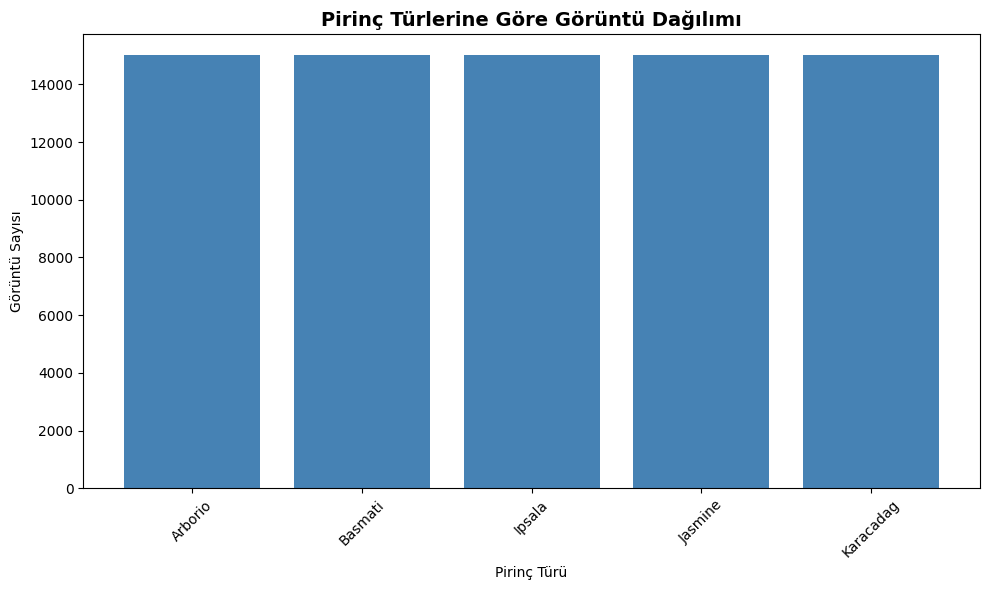

In [ ]:
# ## 3. Veri Ön İşleme ve Keşifsel Analiz

# %%
# Dataset yapısını incele
rice_varieties = ['Arborio', 'Basmati', 'Ipsala', 'Jasmine', 'Karacadag']

# Görüntü sayılarını say
image_counts = {}
for variety in rice_varieties:
    variety_path = os.path.join(DATASET_PATH, variety)
    if os.path.exists(variety_path):
        count = len([f for f in os.listdir(variety_path) if f.endswith(('.jpg', '.png'))])
        image_counts[variety] = count

print("Dataset Dağılımı:")
for variety, count in image_counts.items():
    print(f"{variety}: {count:,} görüntü")

# Dağılımı görselleştir
plt.figure(figsize=(10, 6))
plt.bar(image_counts.keys(), image_counts.values(), color='steelblue')
plt.title('Pirinç Türlerine Göre Görüntü Dağılımı', fontsize=14, fontweight='bold')
plt.xlabel('Pirinç Türü')
plt.ylabel('Görüntü Sayısı')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


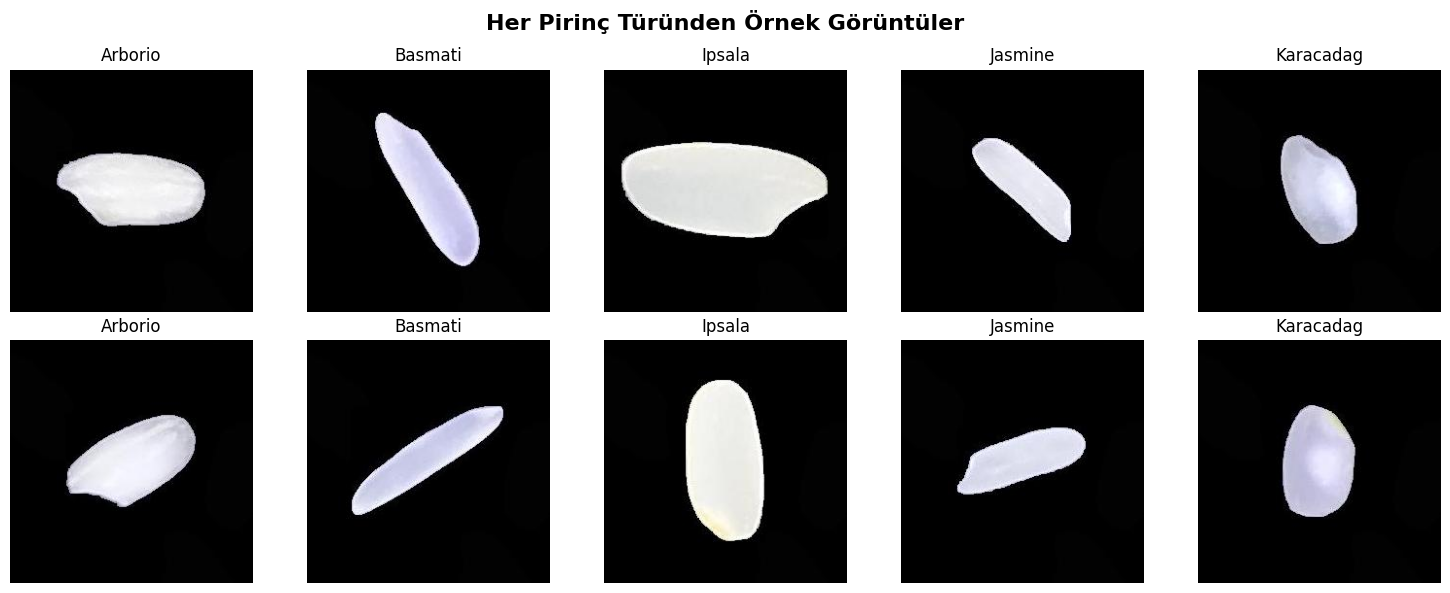

In [ ]:
# ## 4. Örnek Görüntüleri Görselleştirme

# %%
# Her sınıftan örnek görüntüler göster
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Her Pirinç Türünden Örnek Görüntüler', fontsize=16, fontweight='bold')

for idx, variety in enumerate(rice_varieties):
    variety_path = os.path.join(DATASET_PATH, variety)
    images = [f for f in os.listdir(variety_path) if f.endswith(('.jpg', '.png'))][:2]

    for i, img_name in enumerate(images):
        img_path = os.path.join(variety_path, img_name)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        axes[i, idx].imshow(img)
        axes[i, idx].set_title(variety)
        axes[i, idx].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# ## 5. Data Augmentation ve Generator Oluşturma

# %%
# Training için data augmentation (literatür önerileri)
train_datagen = ImageDataGenerator(
    rescale=1./255,                  # [0,1] normalization
    rotation_range=30,               # ±30° rotation
    horizontal_flip=True,            # Horizontal flip
    vertical_flip=True,              # Vertical flip
    width_shift_range=0.1,           # ±10% translation
    height_shift_range=0.1,
    zoom_range=0.3,                  # 0.7x-1.3x zoom
    brightness_range=[0.8, 1.2],     # ±20% brightness
    shear_range=0.15,                # Shearing
    fill_mode='nearest',
    validation_split=0.2             # 80% train, 20% validation
)

# Test için sadece rescaling (NO augmentation)
test_datagen = ImageDataGenerator(rescale=1./255)

# Training generator
train_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

# Validation generator
validation_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

# Class indices
class_indices = train_generator.class_indices
print("\nClass mapping:")
for name, idx in class_indices.items():
    print(f"  {name}: {idx}")

Found 60000 images belonging to 5 classes.
Found 15000 images belonging to 5 classes.

Class mapping:
  Arborio: 0
  Basmati: 1
  Ipsala: 2
  Jasmine: 3
  Karacadag: 4


In [ ]:
# ## 6. Custom CNN Model Mimarisi Tasarımı
#
# **Literatür tabanlı optimal konfigürasyon:**
# - 3 konvolüsyonel blok (32→64→128 filtre progression)
# - 3×3 kernel size (VGG prensibi)
# - MaxPooling 2×2 her blok sonunda
# - Batch Normalization (training stability)
# - L2 regularization (overfitting prevention)
# - Dropout (0.2 conv layers, 0.5 dense layers)

# %%
def create_custom_rice_cnn(input_shape=(224, 224, 3), num_classes=5):
    """
    Pirinç sınıflandırması için optimize edilmiş custom CNN
    Literatür best practices ile tasarlanmıştır
    """
    model = keras.Sequential([
        # BLOCK 1: 32 filters
        layers.Conv2D(32, (3, 3), padding='same',
                     kernel_regularizer=regularizers.l2(0.0001),
                     input_shape=input_shape),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(32, (3, 3), padding='same',
                     kernel_regularizer=regularizers.l2(0.0001)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.SpatialDropout2D(0.2),

        # BLOCK 2: 64 filters
        layers.Conv2D(64, (3, 3), padding='same',
                     kernel_regularizer=regularizers.l2(0.0001)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(64, (3, 3), padding='same',
                     kernel_regularizer=regularizers.l2(0.0001)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.SpatialDropout2D(0.2),

        # BLOCK 3: 128 filters
        layers.Conv2D(128, (3, 3), padding='same',
                     kernel_regularizer=regularizers.l2(0.0001)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(128, (3, 3), padding='same',
                     kernel_regularizer=regularizers.l2(0.0001)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.SpatialDropout2D(0.25),

        # DENSE LAYERS
        layers.Flatten(),
        layers.Dense(512, kernel_regularizer=regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.5),

        layers.Dense(256, kernel_regularizer=regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.5),

        # OUTPUT LAYER
        layers.Dense(num_classes, activation='softmax')
    ])

    return model

# Model oluştur
model = create_custom_rice_cnn(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES)

# Model summary
model.summary()

# Model parametre sayısı
total_params = model.count_params()
print(f"\nToplam parametre sayısı: {total_params:,}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d               │ (None, 112, 112, 32)   │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_1             │ (None, 56, 56, 64)     │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 51,805,221 (197.62 MB)

 Trainable params: 51,802,789 (197.61 MB)

 Non-trainable params: 2,432 (9.50 KB)


Toplam parametre sayısı: 51,805,221


visualkeras kütüphanesi yükleniyor...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 27.7 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/visualkeras/layered.py:86: UserWarning: The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.
  warnings.warn("The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.")


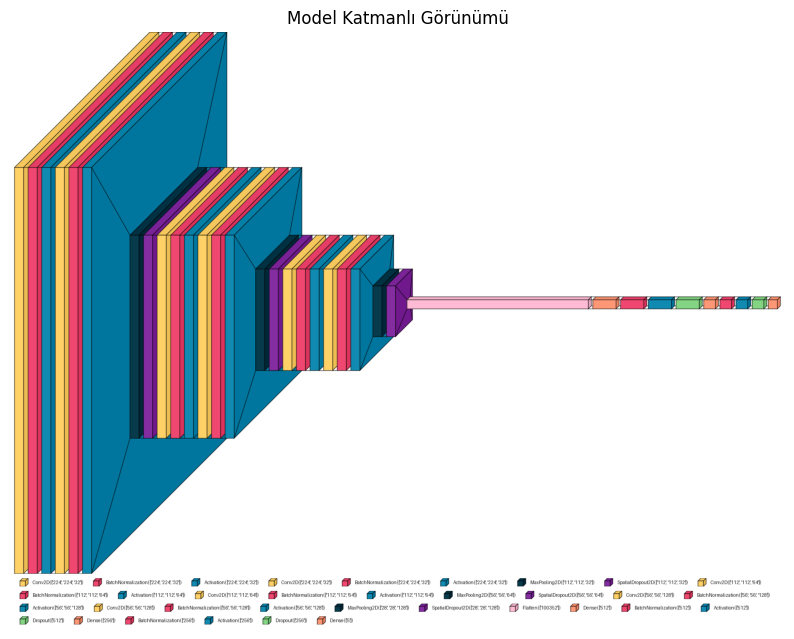

In [ ]:
# ## 7. Model Mimarisini Görselleştirme
# visualkeras kütüphanesini yükleme ve import etme
try:
    import visualkeras
except ImportError:
    print("visualkeras kütüphanesi yükleniyor...")
    !pip install visualkeras
    import visualkeras

# %%
# Katmanlı Görünüm (Layered View)
try:
    img = visualkeras.layered_view(model, legend=True, show_dimension=True)

    # Matplotlib kullanarak resmi görüntüleme:
    plt.figure(figsize=(10, 10))
    plt.imshow(img)
    plt.axis('off')
    plt.title("Model Katmanlı Görünümü")
    plt.show()
except Exception as e:
    print(f"Visualkeras ile görselleştirme sırasında hata: {e}")


In [ ]:
# ## 8. Model Derleme (Compilation)

# %%
# Model compile
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model başarıyla derlendi!")

Model başarıyla derlendi!


In [ ]:
# ## 9. Callbacks Tanımlama (Overfitting Prevention)

# %%
# Callbacks - Best practices
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=15,
        min_delta=0.001,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath='best_rice_model.keras',
        monitor='val_loss',
        mode='min',
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=7,
        min_lr=1e-7,
        verbose=1
    )
]


In [ ]:
# ## 10. Model Eğitimi (Training)

# %%
# Training başlat
EPOCHS = 20

print("Model eğitimi başlıyor...")
print(f"Training samples: {train_generator.samples}")
print(f"Validation samples: {validation_generator.samples}")
print(f"Batch size: {BATCH_SIZE}")

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=validation_generator,
    callbacks=callbacks,
    verbose=1
)

print("\n✓ Model eğitimi tamamlandı!")

Model eğitimi başlıyor...
Training samples: 60000
Validation samples: 15000
Batch size: 64


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 0s 781ms/step - accuracy: 0.6993 - loss: 2.2260
Epoch 1: val_loss improved from inf to 0.96916, saving model to best_rice_model.keras
938/938 ━━━━━━━━━━━━━━━━━━━━ 952s 984ms/step - accuracy: 0.6994 - loss: 2.2253 - val_accuracy: 0.8679 - val_loss: 0.9692 - learning_rate: 0.0010
Epoch 2/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 0s 762ms/step - accuracy: 0.8907 - loss: 0.9090
Epoch 2: val_loss improved from 0.96916 to 0.83969, saving model to best_rice_model.keras
938/938 ━━━━━━━━━━━━━━━━━━━━ 896s 956ms/step - accuracy: 0.8907 - loss: 0.9089 - val_accuracy: 0.8955 - val_loss: 0.8397 - learning_rate: 0.0010
Epoch 3/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 0s 764ms/step - accuracy: 0.9038 - loss: 0.8495
Epoch 3: val_loss improved from 0.83969 to 0.74422, saving model to best_rice_model.keras
938/938 ━━━━━━━━━━━━━━━━━━━━ 897s 956ms/step - accuracy: 0.9038 - loss: 0.8495 - val_accuracy: 0.9362 - val_loss: 0.7442 - learning_rate: 0.0010
Epoch 4/20
938/938 ━━━━━━━━━━━━━━━━

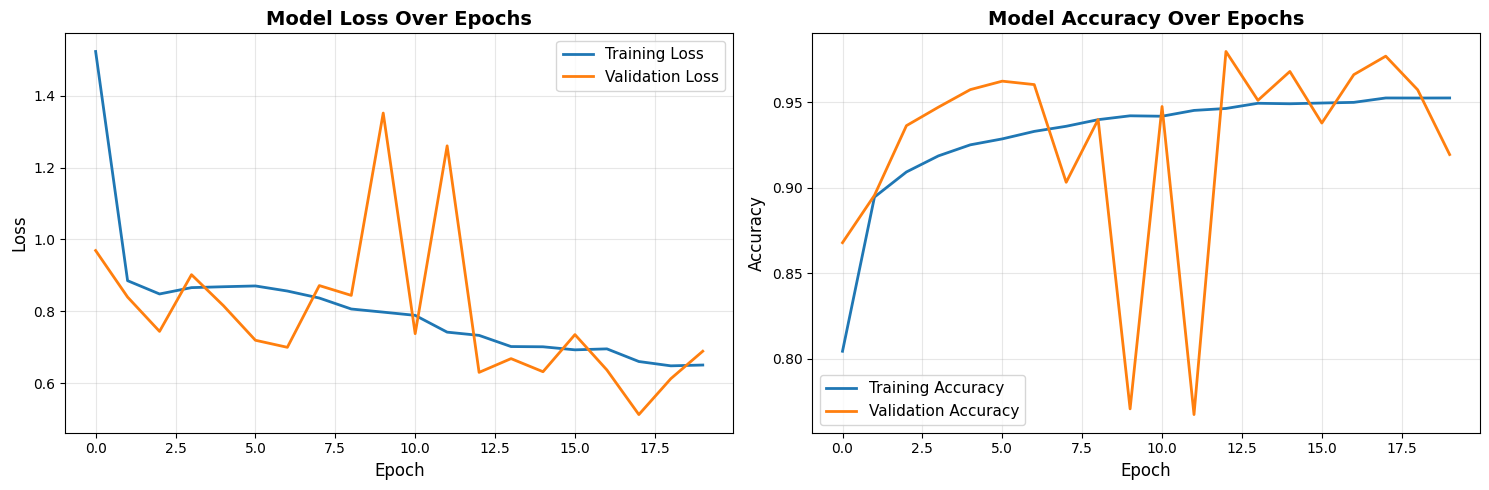


TRAINING SUMMARY
Final Training Loss:     0.6507
Final Validation Loss:   0.6891
Final Training Accuracy: 0.9524 (95.24%)
Final Val Accuracy:      0.9193 (91.93%)
Val/Train Loss Ratio:    1.0591

Validation Loss Stability:
  Std Dev: 0.2027
  Range:   0.8389 (min: 0.5128, max: 1.3517)

MODEL DIAGNOSTICS
✓  Model genel olarak iyi performans gösteriyor


In [ ]:
# ## 11. Training Sonuçlarını Görselleştirme

# %%
# Training history plot
def plot_training_history(history):
    """Training ve validation metrics'i görselleştir"""
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Loss plot
    axes[0].plot(history.history['loss'], label='Training Loss', linewidth=2)
    axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    axes[0].set_title('Model Loss Over Epochs', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].legend(fontsize=11)
    axes[0].grid(alpha=0.3)

    # Accuracy plot
    axes[1].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
    axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
    axes[1].set_title('Model Accuracy Over Epochs', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Accuracy', fontsize=12)
    axes[1].legend(fontsize=11)
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Overfitting detection
    final_train_loss = history.history['loss'][-1]
    final_val_loss = history.history['val_loss'][-1]
    overfitting_ratio = final_val_loss / final_train_loss

    final_train_acc = history.history['accuracy'][-1]
    final_val_acc = history.history['val_accuracy'][-1]

    # Validation loss instability check
    val_losses = history.history['val_loss']
    val_loss_std = np.std(val_losses)
    val_loss_range = max(val_losses) - min(val_losses)

    print("\n" + "="*70)
    print("TRAINING SUMMARY")
    print("="*70)
    print(f"Final Training Loss:     {final_train_loss:.4f}")
    print(f"Final Validation Loss:   {final_val_loss:.4f}")
    print(f"Final Training Accuracy: {final_train_acc:.4f} ({final_train_acc*100:.2f}%)")
    print(f"Final Val Accuracy:      {final_val_acc:.4f} ({final_val_acc*100:.2f}%)")
    print(f"Val/Train Loss Ratio:    {overfitting_ratio:.4f}")
    print(f"\nValidation Loss Stability:")
    print(f"  Std Dev: {val_loss_std:.4f}")
    print(f"  Range:   {val_loss_range:.4f} (min: {min(val_losses):.4f}, max: {max(val_losses):.4f})")

    # Detailed diagnostics
    print("\n" + "="*70)
    print("MODEL DIAGNOSTICS")
    print("="*70)

    if val_loss_std > 0.3:
        print("⚠️  YÜKSEK VALİDATION LOSS DALGALANMASI!")
        print("   → Batch size çok büyük (256). 32-64 deneyin.")
        print("   → Learning rate çok yüksek (0.0015). 0.0001-0.0003 deneyin.")
        print("   → Data augmentation aşırı agresif olabilir.")

    if overfitting_ratio > 1.2:
        print("⚠️  OVERFITTING TESPİT EDİLDİ!")
        print("   → Daha fazla regularization ekleyin")
        print("   → Dropout rate'leri artırın (0.3-0.6)")
        print("   → Daha fazla data augmentation")
    elif final_val_acc < 0.85:
        print("⚠️  UNDERFITTING OLABİLİR")
        print("   → Model kapasitesini artırın")
        print("   → Daha uzun train edin")
        print("   → Learning rate'i optimize edin")
    else:
        print("✓  Model genel olarak iyi performans gösteriyor")

plot_training_history(history)


In [ ]:
# ## 12. Model Değerlendirmesi (Validation Set)

# %%
# Validation set performansı
val_loss, val_accuracy = model.evaluate(validation_generator, verbose=1)

print("\n" + "="*70)
print("VALIDATION SET EVALUATION")
print("="*70)
print(f"Validation Loss:     {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f} ({val_accuracy*100:.2f}%)")
print("="*70)


235/235 ━━━━━━━━━━━━━━━━━━━━ 178s 757ms/step - accuracy: 0.9763 - loss: 0.5204

VALIDATION SET EVALUATION
Validation Loss:     0.5107
Validation Accuracy: 0.9790 (97.90%)


In [ ]:
# ## 13. Confusion Matrix ve Classification Report

# %%
# Predictions al
print("\nTahminler yapılıyor...")
validation_generator.reset()
y_pred_probs = model.predict(validation_generator, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = validation_generator.classes

# Class names
class_names = list(class_indices.keys())

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Confusion Matrix görselleştir
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            ax=axes[0], cbar_kws={'label': 'Count'})
axes[0].set_title('Confusion Matrix (Counts)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted Label', fontsize=12)
axes[0].set_ylabel('True Label', fontsize=12)

# Normalized
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names,
            ax=axes[1], cbar_kws={'label': 'Percentage'})
axes[1].set_title('Confusion Matrix (Normalized)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Predicted Label', fontsize=12)
axes[1].set_ylabel('True Label', fontsize=12)

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Classification Report
print("\n" + "="*70)
print("CLASSIFICATION REPORT")
print("="*70)
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))


In [ ]:
# ## 14. Per-Class Accuracy Analizi

# %%
# Her sınıf için detaylı analiz
class_accuracies = cm.diagonal() / cm.sum(axis=1)

plt.figure(figsize=(10, 6))
bars = plt.bar(class_names, class_accuracies, color='steelblue', alpha=0.8)
plt.axhline(y=val_accuracy, color='red', linestyle='--',
           label=f'Overall Accuracy: {val_accuracy:.2%}')
plt.title('Per-Class Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Rice Variety', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.ylim([0, 1.05])
plt.xticks(rotation=45)
plt.legend()

# Bar'ların üstüne değerleri yaz
for bar, acc in zip(bars, class_accuracies):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{acc:.2%}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('per_class_accuracy.png', dpi=300, bbox_inches='tight')
plt.show()

# Hangi sınıflar zor?
print("\n" + "="*70)
print("PER-CLASS PERFORMANCE SUMMARY")
print("="*70)
for name, acc in zip(class_names, class_accuracies):
    status = "✓" if acc > 0.90 else "⚠️" if acc > 0.80 else "❌"
    print(f"{status} {name:12s}: {acc:.2%}")
print("="*70)



Toplam doğru tahmin:  14634 / 15000 (97.56%)
Toplam yanlış tahmin: 366 / 15000 (2.44%)

DOĞRU TAHMİN ÖRNEKLERİ (5 Adet)


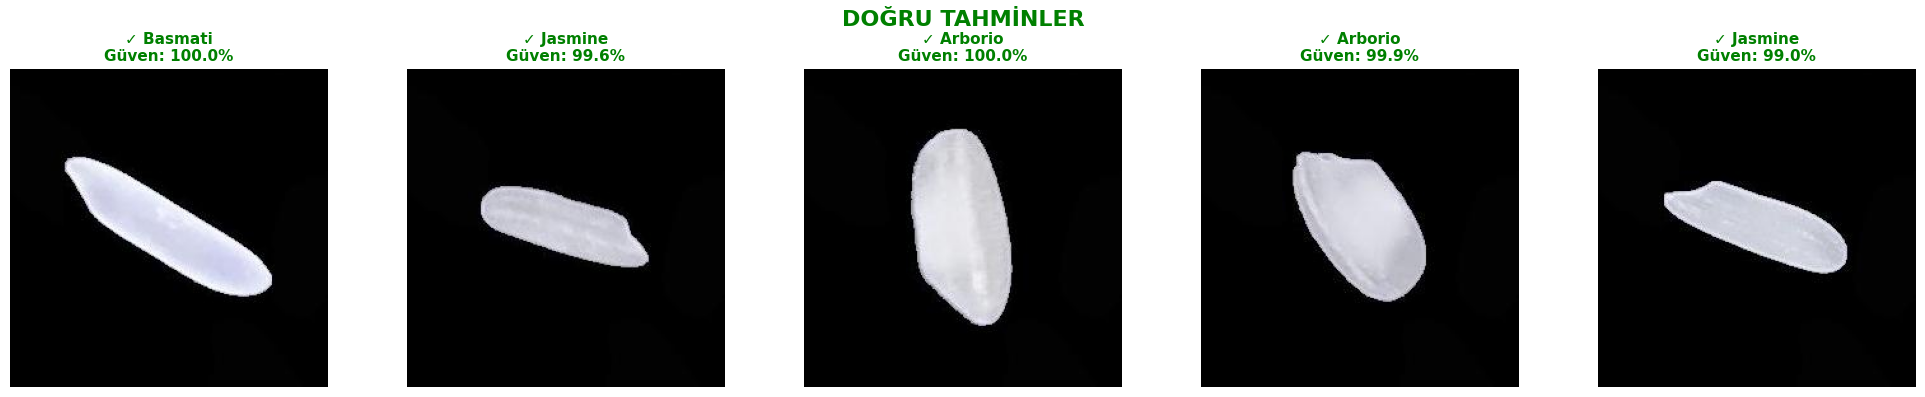

In [ ]:
# ## 15. DOĞRU Tahmin Örnekleri (5 Adet)

# %%
# Doğru ve yanlış tahminleri bul
correct_indices = np.where(y_pred == y_true)[0]
incorrect_indices = np.where(y_pred != y_true)[0]

print(f"\nToplam doğru tahmin:  {len(correct_indices)} / {len(y_true)} ({len(correct_indices)/len(y_true)*100:.2f}%)")
print(f"Toplam yanlış tahmin: {len(incorrect_indices)} / {len(y_true)} ({len(incorrect_indices)/len(y_true)*100:.2f}%)")

# Görüntüleri yeniden yükle (generator'dan değil, direkt dosyadan)
def load_sample_images(indices, y_true, y_pred, y_pred_probs, class_names, sample_size=5):
    """Belirtilen indekslerden görüntüleri yükle"""
    sample_indices = np.random.choice(indices, min(sample_size, len(indices)), replace=False)

    images = []
    labels = []

    for idx in sample_indices:
        true_class_idx = y_true[idx]
        true_class = class_names[true_class_idx]

        # Dosya yolunu bul
        variety_path = os.path.join(DATASET_PATH, true_class)
        image_files = [f for f in os.listdir(variety_path) if f.endswith(('.jpg', '.png'))]

        # Validation set'teki idx'e karşılık gelen dosyayı bul
        # Validation generator shuffle=False olduğu için sıralı
        val_start_idx = int(0.8 * len(image_files))  # 80% train, 20% validation
        relative_idx = idx % len(image_files)

        if relative_idx < len(image_files) - val_start_idx:
            img_file = image_files[val_start_idx + relative_idx]
            img_path = os.path.join(variety_path, img_file)

            img = cv2.imread(img_path)
            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                images.append(img)
                labels.append({
                    'true_label': true_class,
                    'pred_label': class_names[y_pred[idx]],
                    'confidence': y_pred_probs[idx][y_pred[idx]] * 100,
                    'all_probs': y_pred_probs[idx]
                })

    return images, labels

# Doğru tahmin örnekleri göster
if len(correct_indices) > 0:
    print("\n" + "="*70)
    print("DOĞRU TAHMİN ÖRNEKLERİ (5 Adet)")
    print("="*70)

    # Basit yöntem: Her sınıftan birer örnek al
    fig, axes = plt.subplots(1, 5, figsize=(20, 4))
    fig.suptitle('DOĞRU TAHMİNLER', fontsize=16, fontweight='bold', color='green')

    sample_correct = np.random.choice(correct_indices, min(5, len(correct_indices)), replace=False)

    for i, idx in enumerate(sample_correct):
        true_class = class_names[y_true[idx]]
        pred_class = class_names[y_pred[idx]]
        confidence = y_pred_probs[idx][y_pred[idx]] * 100

        # Görüntüyü yükle
        variety_path = os.path.join(DATASET_PATH, true_class)
        image_files = sorted([f for f in os.listdir(variety_path) if f.endswith(('.jpg', '.png'))])

        # Validation set'ten rastgele bir görüntü seç
        val_images = image_files[int(0.8*len(image_files)):]
        if val_images:
            img_file = np.random.choice(val_images)
            img_path = os.path.join(variety_path, img_file)
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            axes[i].imshow(img)
            axes[i].set_title(f'✓ {true_class}\nGüven: {confidence:.1f}%',
                            fontsize=11, color='green', fontweight='bold')
            axes[i].axis('off')

    plt.tight_layout()
    plt.savefig('correct_predictions.png', dpi=300, bbox_inches='tight')
    plt.show()



⚠️  YANLIŞ TAHMİN ÖRNEKLERİ (5 Adet)


/tmp/ipython-input-48855322.py:61: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-48855322.py:62: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('incorrect_predictions.png', dpi=300, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


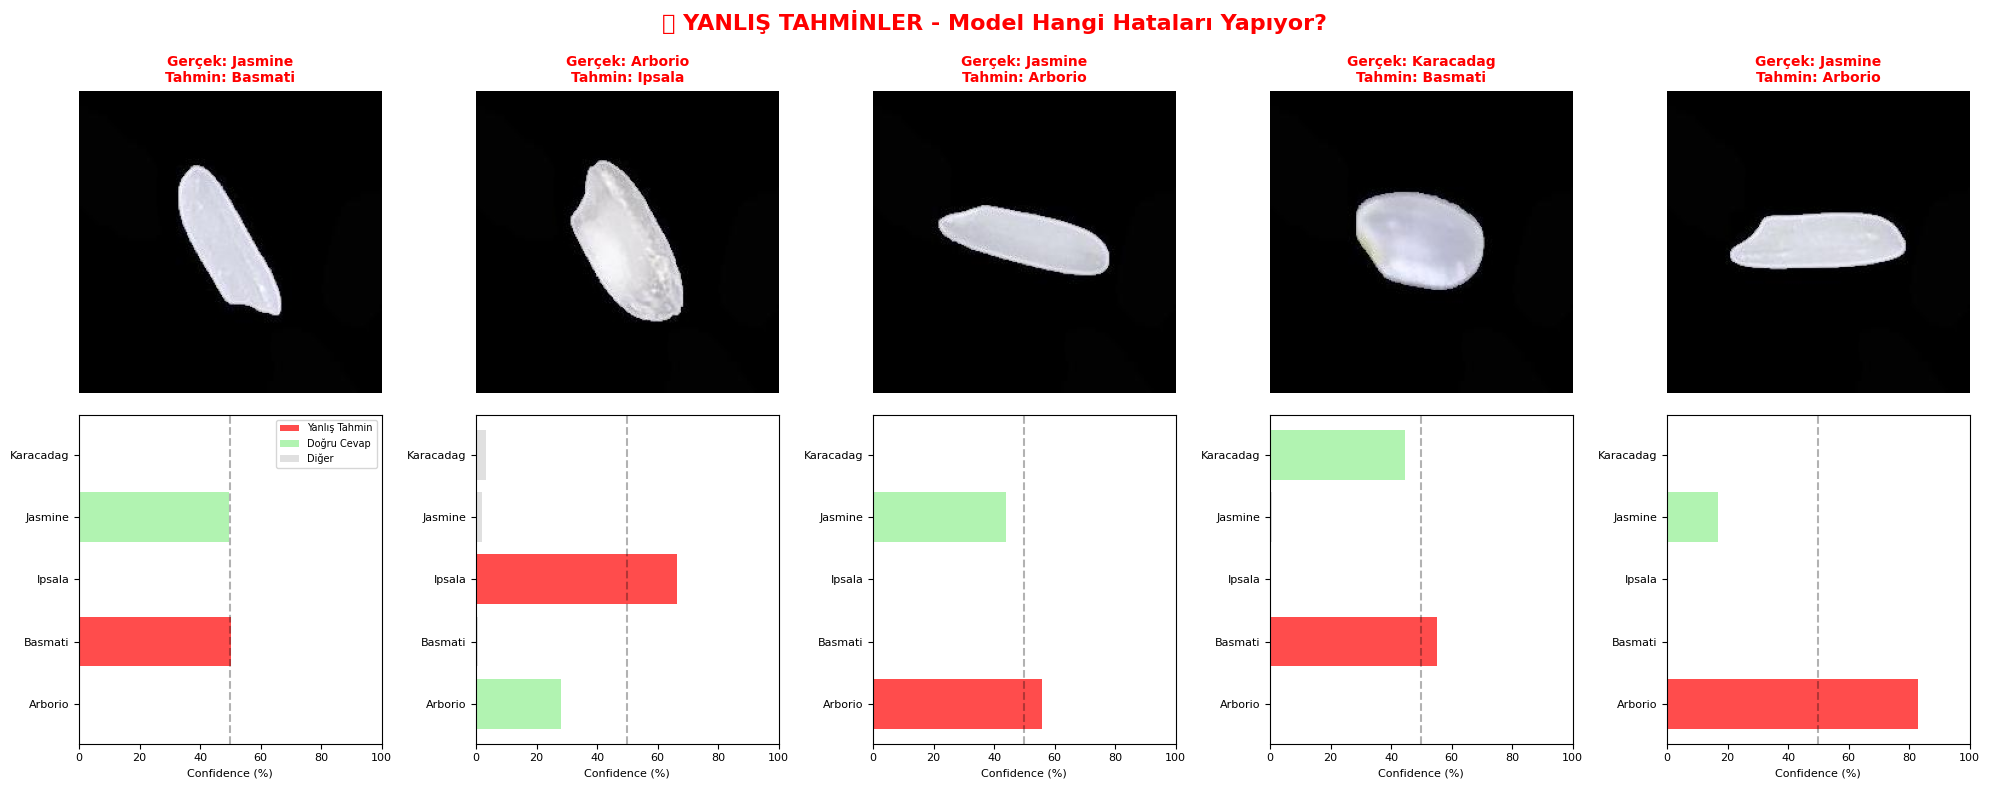


Yanlış Tahmin Detayları:
----------------------------------------------------------------------
1. Gerçek: Jasmine      → Tahmin: Basmati     
   Yanlış tahmin güveni: 50.10%
   Doğru cevap güveni:   49.63%
   Fark: 0.47%

2. Gerçek: Arborio      → Tahmin: Ipsala      
   Yanlış tahmin güveni: 66.54%
   Doğru cevap güveni:   27.94%
   Fark: 38.60%

3. Gerçek: Jasmine      → Tahmin: Arborio     
   Yanlış tahmin güveni: 55.87%
   Doğru cevap güveni:   43.93%
   Fark: 11.94%

4. Gerçek: Karacadag    → Tahmin: Basmati     
   Yanlış tahmin güveni: 55.07%
   Doğru cevap güveni:   44.44%
   Fark: 10.63%

5. Gerçek: Jasmine      → Tahmin: Arborio     
   Yanlış tahmin güveni: 82.97%
   Doğru cevap güveni:   16.76%
   Fark: 66.21%



In [ ]:
# ## 16. ⚠️ YANLIŞ Tahmin Örnekleri (5 Adet) - MUTLAKA

# %%
if len(incorrect_indices) > 0:
    print("\n" + "="*70)
    print("⚠️  YANLIŞ TAHMİN ÖRNEKLERİ (5 Adet)")
    print("="*70)

    fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    fig.suptitle('❌ YANLIŞ TAHMİNLER - Model Hangi Hataları Yapıyor?',
                 fontsize=16, fontweight='bold', color='red')

    sample_incorrect = np.random.choice(incorrect_indices, min(5, len(incorrect_indices)), replace=False)

    for i, idx in enumerate(sample_incorrect):
        true_class = class_names[y_true[idx]]
        pred_class = class_names[y_pred[idx]]
        confidence = y_pred_probs[idx][y_pred[idx]] * 100
        true_confidence = y_pred_probs[idx][y_true[idx]] * 100

        # Görüntüyü yükle
        variety_path = os.path.join(DATASET_PATH, true_class)
        image_files = sorted([f for f in os.listdir(variety_path) if f.endswith(('.jpg', '.png'))])

        val_images = image_files[int(0.8*len(image_files)):]
        if val_images:
            # İlgili indexteki dosyayı bul
            img_file = val_images[idx % len(val_images)]
            img_path = os.path.join(variety_path, img_file)
            img = cv2.imread(img_path)
            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

                # Üst satır: Görüntü
                axes[0, i].imshow(img)
                axes[0, i].set_title(f'Gerçek: {true_class}\nTahmin: {pred_class}',
                                    fontsize=10, color='red', fontweight='bold')
                axes[0, i].axis('off')

                # Alt satır: Confidence bar chart
                all_confidences = y_pred_probs[idx] * 100
                colors = ['red' if j == y_pred[idx] else 'lightgreen' if j == y_true[idx] else 'lightgray'
                         for j in range(len(class_names))]

                axes[1, i].barh(class_names, all_confidences, color=colors, alpha=0.7)
                axes[1, i].set_xlim([0, 100])
                axes[1, i].set_xlabel('Confidence (%)', fontsize=8)
                axes[1, i].tick_params(axis='both', labelsize=8)
                axes[1, i].axvline(x=50, color='black', linestyle='--', alpha=0.3)

                # Legend ekle
                if i == 0:
                    from matplotlib.patches import Patch
                    legend_elements = [
                        Patch(facecolor='red', alpha=0.7, label='Yanlış Tahmin'),
                        Patch(facecolor='lightgreen', alpha=0.7, label='Doğru Cevap'),
                        Patch(facecolor='lightgray', alpha=0.7, label='Diğer')
                    ]
                    axes[1, i].legend(handles=legend_elements, fontsize=7, loc='upper right')

    plt.tight_layout()
    plt.savefig('incorrect_predictions.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Yanlış tahminlerin detaylı analizi
    print("\nYanlış Tahmin Detayları:")
    print("-" * 70)
    for i, idx in enumerate(sample_incorrect, 1):
        true_class = class_names[y_true[idx]]
        pred_class = class_names[y_pred[idx]]
        confidence = y_pred_probs[idx][y_pred[idx]] * 100
        true_confidence = y_pred_probs[idx][y_true[idx]] * 100

        print(f"{i}. Gerçek: {true_class:12s} → Tahmin: {pred_class:12s}")
        print(f"   Yanlış tahmin güveni: {confidence:.2f}%")
        print(f"   Doğru cevap güveni:   {true_confidence:.2f}%")
        print(f"   Fark: {confidence - true_confidence:.2f}%")
        print()

else:
    print("\n🎉 MÜKEMMEL! Validation set'te hiç yanlış tahmin yok!")


## C

In [ ]:
# ==========================================
# RICE IMAGE DATASET - WGET İLE İNDİRME VE CNN CLASSIFIER
# 5-Class Rice Variety Classification
# ==========================================


# # Rice Image Dataset Sınıflandırması
#
# Bu notebook, Rice Image Dataset'i wget ile indirir ve sıfırdan özel CNN modeli tasarlar.
# Dataset: 75,000 RGB görüntü, 5 pirinç türü (Arborio, Basmati, Ipsala, Jasmine, Karacadag)


# ## 1. Veri Setini İndirme (Wget ile Direkt İndirme)

# %%
import os
import subprocess
import zipfile
import glob
from pathlib import Path

def download_dataset_direct(download_url, dest_folder, zip_filename):
    """
    Belirtilen URL'den wget ile veri seti zip dosyasını indirir.
    İndirilen dosya, dest_folder içine zip_filename olarak kaydedilir.
    """
    if not os.path.exists(dest_folder):
        os.makedirs(dest_folder)

    full_zip_path = os.path.join(dest_folder, zip_filename)

    print(f"\n{zip_filename} indiriliyor...\nURL: {download_url}")
    print("Bu işlem birkaç dakika sürebilir (Dataset ~1.2 GB)...")

    try:
        cmd = ["wget", "-O", full_zip_path, download_url]
        subprocess.run(cmd, check=True)
        print(f"{zip_filename} başarıyla indirildi: {full_zip_path}")
        return True
    except Exception as e:
        print(f"İndirme hatası ({zip_filename}): {e}")
        return False

def extract_dataset(dest_folder):
    """İndirilen zip dosyasını açar"""
    try:
        zip_files = glob.glob(os.path.join(dest_folder, "*.zip"))
        if not zip_files:
            print(f"Uyarı: {dest_folder} klasöründe zip dosyası bulunamadı")
            return False

        for zip_file in zip_files:
            print(f"Zip dosyası açılıyor: {zip_file}")
            with zipfile.ZipFile(zip_file, 'r') as zip_ref:
                zip_ref.extractall(dest_folder)

            # Zip dosyasını sil (disk alanı tasarrufu)
            os.remove(zip_file)
            print(f"Zip dosyası silindi: {zip_file}")

        print(f"Dataset başarıyla açıldı: {dest_folder}")
        return True
    except Exception as e:
        print(f"Zip açma hatası: {e}")
        return False

# Ana klasörü oluştur
dataset_folder = "rice_dataset"
if not os.path.exists(dataset_folder):
    os.makedirs(dataset_folder)
    print(f"Klasör oluşturuldu: {dataset_folder}")

# Rice Image Dataset bilgileri
rice_dataset_info = {
    "name": "rice-image-dataset",
    "download_url": "https://www.kaggle.com/api/v1/datasets/download/muratkokludataset/rice-image-dataset",
    "folder": dataset_folder,
    "zip_filename": "rice-image-dataset.zip"
}

# Dataset zaten var mı kontrol et
rice_dataset_path = os.path.join(dataset_folder, "Rice_Image_Dataset")
if os.path.exists(rice_dataset_path):
    print("\n" + "="*60)
    print("Dataset zaten mevcut, indirme atlanıyor...")
    print("="*60)
else:
    # İndirme işlemi
    print("\n" + "="*60)
    print("RICE IMAGE DATASET İNDİRİLİYOR")
    print("="*60)

    download_success = download_dataset_direct(
        rice_dataset_info["download_url"],
        rice_dataset_info["folder"],
        rice_dataset_info["zip_filename"]
    )

    if download_success:
        # Zip dosyasını aç
        print("\n" + "="*60)
        print("ZIP DOSYASI AÇILIYOR")
        print("="*60)
        extract_dataset(rice_dataset_info["folder"])
    else:
        print("\n❌ İndirme başarısız!")
        print("\nMANUEL İNDİRME TALİMATLARI:")
        print("1. https://www.kaggle.com/datasets/muratkokludataset/rice-image-dataset")
        print("2. 'Download' butonuna tıklayın")
        print(f"3. İndirilen zip'i {dataset_folder}/ klasörüne koyun")
        print("4. Bu notebook'u tekrar çalıştırın")

# Dataset yapısını kontrol et ve göster
if os.path.exists(rice_dataset_path):
    print("\n" + "="*60)
    print("DATASET YAPISI")
    print("="*60)

    rice_varieties = [d for d in os.listdir(rice_dataset_path)
                     if os.path.isdir(os.path.join(rice_dataset_path, d))]

    total_images = 0
    for variety in rice_varieties:
        variety_path = os.path.join(rice_dataset_path, variety)
        count = len([f for f in os.listdir(variety_path)
                    if f.endswith(('.jpg', '.png', '.jpeg'))])
        print(f"  {variety}: {count:,} görüntü")
        total_images += count

    print(f"\nToplam: {total_images:,} görüntü")
    print("="*60)
    print("\n✅ Dataset başarıyla hazır!")


Klasör oluşturuldu: rice_dataset

RICE IMAGE DATASET İNDİRİLİYOR

rice-image-dataset.zip indiriliyor...
URL: https://www.kaggle.com/api/v1/datasets/download/muratkokludataset/rice-image-dataset
Bu işlem birkaç dakika sürebilir (Dataset ~1.2 GB)...
rice-image-dataset.zip başarıyla indirildi: rice_dataset/rice-image-dataset.zip

ZIP DOSYASI AÇILIYOR
Zip dosyası açılıyor: rice_dataset/rice-image-dataset.zip
Zip dosyası silindi: rice_dataset/rice-image-dataset.zip
Dataset başarıyla açıldı: rice_dataset

DATASET YAPISI
  Karacadag: 15,000 görüntü
  Jasmine: 15,000 görüntü
  Basmati: 15,000 görüntü
  Arborio: 15,000 görüntü
  Ipsala: 15,000 görüntü

Toplam: 75,000 görüntü

✅ Dataset başarıyla hazır!


TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Dataset Dağılımı:
Arborio: 15,000 görüntü
Basmati: 15,000 görüntü
Ipsala: 15,000 görüntü
Jasmine: 15,000 görüntü
Karacadag: 15,000 görüntü


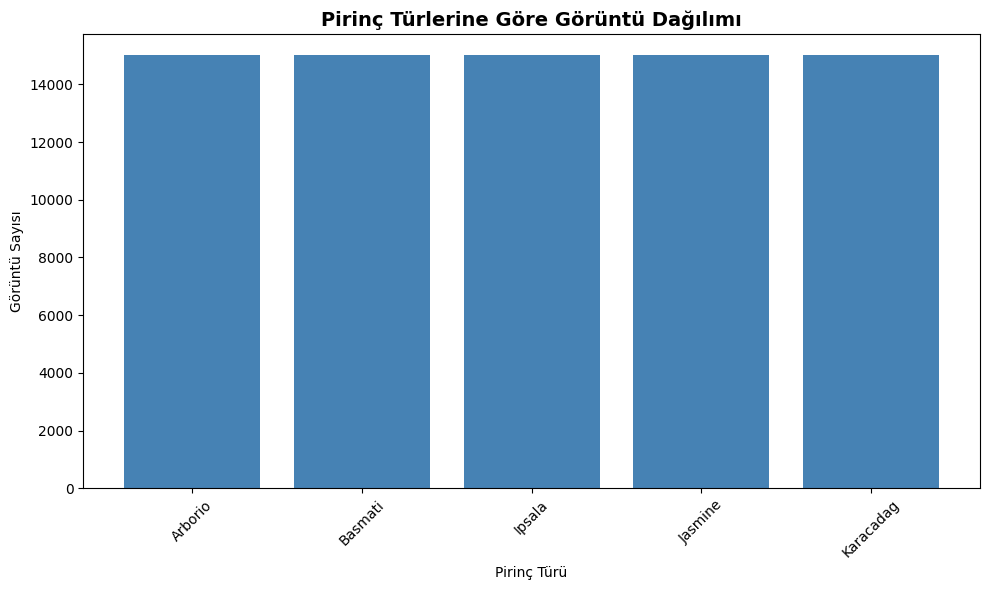

In [ ]:
# ## 2. Kütüphaneler ve Ortam Ayarları

# %%
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import cv2

# Reproducibility için seed ayarla
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

# Dataset path
DATASET_PATH = 'rice_dataset/Rice_Image_Dataset'
IMG_SIZE = 224  # 224x224 için değiştirildi
BATCH_SIZE = 64
NUM_CLASSES = 5


# ## 3. Veri Ön İşleme ve Keşifsel Analiz

# %%
# Dataset yapısını incele
rice_varieties = ['Arborio', 'Basmati', 'Ipsala', 'Jasmine', 'Karacadag']

# Görüntü sayılarını say
image_counts = {}
for variety in rice_varieties:
    variety_path = os.path.join(DATASET_PATH, variety)
    if os.path.exists(variety_path):
        count = len([f for f in os.listdir(variety_path) if f.endswith(('.jpg', '.png'))])
        image_counts[variety] = count

print("Dataset Dağılımı:")
for variety, count in image_counts.items():
    print(f"{variety}: {count:,} görüntü")

# Dağılımı görselleştir
plt.figure(figsize=(10, 6))
plt.bar(image_counts.keys(), image_counts.values(), color='steelblue')
plt.title('Pirinç Türlerine Göre Görüntü Dağılımı', fontsize=14, fontweight='bold')
plt.xlabel('Pirinç Türü')
plt.ylabel('Görüntü Sayısı')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


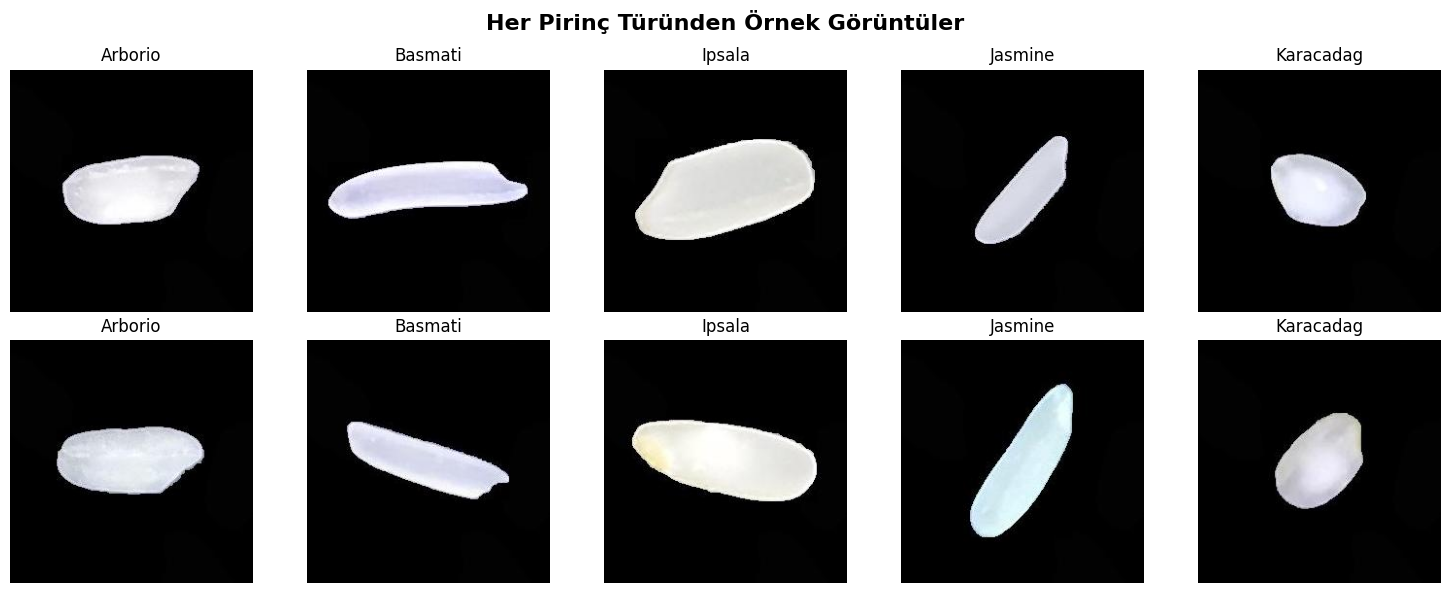

Found 60000 images belonging to 5 classes.
Found 15000 images belonging to 5 classes.

Class mapping:
  Arborio: 0
  Basmati: 1
  Ipsala: 2
  Jasmine: 3
  Karacadag: 4


In [ ]:
# ## 4. Örnek Görüntüleri Görselleştirme

# %%
# Her sınıftan örnek görüntüler göster
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Her Pirinç Türünden Örnek Görüntüler', fontsize=16, fontweight='bold')

for idx, variety in enumerate(rice_varieties):
    variety_path = os.path.join(DATASET_PATH, variety)
    images = [f for f in os.listdir(variety_path) if f.endswith(('.jpg', '.png'))][:2]

    for i, img_name in enumerate(images):
        img_path = os.path.join(variety_path, img_name)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        axes[i, idx].imshow(img)
        axes[i, idx].set_title(variety)
        axes[i, idx].axis('off')

plt.tight_layout()
plt.show()


# ## 5. Data Augmentation ve Generator Oluşturma

# %%
# Training için data augmentation (OPTIMIZED - daha az agresif)
train_datagen = ImageDataGenerator(
    rescale=1./255,                  # [0,1] normalization
    rotation_range=20,               # ±20° (30°'den azaltıldı)
    horizontal_flip=True,            # Horizontal flip
    vertical_flip=True,              # Vertical flip
    width_shift_range=0.1,           # ±10% translation
    height_shift_range=0.1,
    zoom_range=0.2,                  # 0.8x-1.2x zoom (0.3'ten azaltıldı)
    brightness_range=[0.85, 1.15],   # ±15% brightness (daha az agresif)
    shear_range=0.1,                 # Shearing (0.15'ten azaltıldı)
    fill_mode='nearest',
    validation_split=0.2             # 80% train, 20% validation
)

# Test için sadece rescaling (NO augmentation)
test_datagen = ImageDataGenerator(rescale=1./255)

# Training generator
train_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

# Validation generator
validation_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

# Class indices
class_indices = train_generator.class_indices
print("\nClass mapping:")
for name, idx in class_indices.items():
    print(f"  {name}: {idx}")


In [ ]:
# ## 6. Custom CNN Model Mimarisi Tasarımı
#
# **Literatür tabanlı optimal konfigürasyon:**
# - 3 konvolüsyonel blok (32→64→128 filtre progression)
# - 3×3 kernel size (VGG prensibi)
# - MaxPooling 2×2 her blok sonunda
# - Batch Normalization (training stability)
# - L2 regularization (overfitting prevention)
# - Dropout (0.2 conv layers, 0.5 dense layers)

# %%
def create_custom_rice_cnn(input_shape=(224, 224, 3), num_classes=5):
    """
    Pirinç sınıflandırması için optimize edilmiş custom CNN
    Literatür best practices ile tasarlanmıştır
    """
    model = keras.Sequential([
        # BLOCK 1: 32 filters
        layers.Conv2D(32, (3, 3), padding='same',
                     kernel_regularizer=regularizers.l2(0.002),
                     input_shape=input_shape),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(32, (3, 3), padding='same',
                     kernel_regularizer=regularizers.l2(0.002)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.SpatialDropout2D(0.2),

        # BLOCK 2: 64 filters
        layers.Conv2D(64, (3, 3), padding='same',
                     kernel_regularizer=regularizers.l2(0.002)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(64, (3, 3), padding='same',
                     kernel_regularizer=regularizers.l2(0.002)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.SpatialDropout2D(0.2),

        # BLOCK 3: 128 filters
        layers.Conv2D(128, (3, 3), padding='same',
                     kernel_regularizer=regularizers.l2(0.002)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(128, (3, 3), padding='same',
                     kernel_regularizer=regularizers.l2(0.002)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.SpatialDropout2D(0.25),

        # DENSE LAYERS
        layers.Flatten(),
        layers.Dense(512, kernel_regularizer=regularizers.l2(0.002)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.5),

        layers.Dense(256, kernel_regularizer=regularizers.l2(0.002)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.5),

        # OUTPUT LAYER
        layers.Dense(num_classes, activation='softmax')
    ])

    return model

# Model oluştur
model = create_custom_rice_cnn(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES)

# Model summary
model.summary()

# Model parametre sayısı
total_params = model.count_params()
print(f"\nToplam parametre sayısı: {total_params:,}")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d               │ (None, 112, 112, 32)   │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_1             │ (None, 56, 56, 64)     │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 51,805,221 (197.62 MB)

 Trainable params: 51,802,789 (197.61 MB)

 Non-trainable params: 2,432 (9.50 KB)


Toplam parametre sayısı: 51,805,221


In [ ]:
# ## 7. Model Mimarisini Görselleştirme
# visualkeras kütüphanesini yükleme ve import etme
try:
    import visualkeras
except ImportError:
    print("visualkeras kütüphanesi yükleniyor...")
    !pip install visualkeras
    import visualkeras

# %%
# Katmanlı Görünüm (Layered View)
try:
    img = visualkeras.layered_view(model, legend=True, show_dimension=True)

    # Matplotlib kullanarak resmi görüntüleme:
    plt.figure(figsize=(10, 10))
    plt.imshow(img)
    plt.axis('off')
    plt.title("Model Katmanlı Görünümü")
    plt.show()
except Exception as e:
    print(f"Visualkeras ile görselleştirme sırasında hata: {e}")

# ## 8. Model Derleme (Compilation)

# %%
# Model compile - REDUCED LEARNING RATE
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.002),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ## 9. Callbacks Tanımlama (Overfitting Prevention)

# %%
# Callbacks - Best practices
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=15,
        min_delta=0.001,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath='best_rice_model.keras',
        monitor='val_loss',
        mode='min',
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=7,
        min_lr=1e-7,
        verbose=1
    )
]


visualkeras kütüphanesi yükleniyor...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 26.6 MB/s eta 0:00:00
Visualkeras ile görselleştirme sırasında hata: 'Conv2D' object has no attribute 'output_shape'


/usr/local/lib/python3.12/dist-packages/visualkeras/layered.py:231: UserWarning: The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.
  warnings.warn("The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.")


In [ ]:
# ## 10. Model Eğitimi (Training)

# %%
# Training başlat
EPOCHS = 50  # Kullanıcı tercihi (zaman tasarrufu)

print("Model eğitimi başlıyor...")
print(f"Training samples: {train_generator.samples}")
print(f"Validation samples: {validation_generator.samples}")
print(f"Batch size: {BATCH_SIZE}")

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=validation_generator,
    callbacks=callbacks,
    verbose=1
)

print("\n✓ Model eğitimi tamamlandı!")


Model eğitimi başlıyor...
Training samples: 60000
Validation samples: 15000
Batch size: 64


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
 48/938 ━━━━━━━━━━━━━━━━━━━━ 11:17 762ms/step - accuracy: 0.4000 - loss: 8.8386

KeyboardInterrupt: 

In [ ]:
# ## 11. Training Sonuçlarını Görselleştirme

# %%
# Training history plot
def plot_training_history(history):
    """Training ve validation metrics'i görselleştir"""
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Loss plot
    axes[0].plot(history.history['loss'], label='Training Loss', linewidth=2)
    axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    axes[0].set_title('Model Loss Over Epochs', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].legend(fontsize=11)
    axes[0].grid(alpha=0.3)

    # Accuracy plot
    axes[1].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
    axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
    axes[1].set_title('Model Accuracy Over Epochs', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Accuracy', fontsize=12)
    axes[1].legend(fontsize=11)
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Overfitting detection
    final_train_loss = history.history['loss'][-1]
    final_val_loss = history.history['val_loss'][-1]
    overfitting_ratio = final_val_loss / final_train_loss

    final_train_acc = history.history['accuracy'][-1]
    final_val_acc = history.history['val_accuracy'][-1]

    # Validation loss instability check
    val_losses = history.history['val_loss']
    val_loss_std = np.std(val_losses)
    val_loss_range = max(val_losses) - min(val_losses)

    print("\n" + "="*70)
    print("TRAINING SUMMARY")
    print("="*70)
    print(f"Final Training Loss:     {final_train_loss:.4f}")
    print(f"Final Validation Loss:   {final_val_loss:.4f}")
    print(f"Final Training Accuracy: {final_train_acc:.4f} ({final_train_acc*100:.2f}%)")
    print(f"Final Val Accuracy:      {final_val_acc:.4f} ({final_val_acc*100:.2f}%)")
    print(f"Val/Train Loss Ratio:    {overfitting_ratio:.4f}")
    print(f"\nValidation Loss Stability:")
    print(f"  Std Dev: {val_loss_std:.4f}")
    print(f"  Range:   {val_loss_range:.4f} (min: {min(val_losses):.4f}, max: {max(val_losses):.4f})")

    # Detailed diagnostics
    print("\n" + "="*70)
    print("MODEL DIAGNOSTICS")
    print("="*70)

    if val_loss_std > 0.3:
        print("⚠️  YÜKSEK VALİDATION LOSS DALGALANMASI!")
        print("   → Batch size çok büyük (256). 32-64 deneyin.")
        print("   → Learning rate çok yüksek (0.0015). 0.0001-0.0003 deneyin.")
        print("   → Data augmentation aşırı agresif olabilir.")

    if overfitting_ratio > 1.2:
        print("⚠️  OVERFITTING TESPİT EDİLDİ!")
        print("   → Daha fazla regularization ekleyin")
        print("   → Dropout rate'leri artırın (0.3-0.6)")
        print("   → Daha fazla data augmentation")
    elif final_val_acc < 0.85:
        print("⚠️  UNDERFITTING OLABİLİR")
        print("   → Model kapasitesini artırın")
        print("   → Daha uzun train edin")
        print("   → Learning rate'i optimize edin")
    else:
        print("✓  Model genel olarak iyi performans gösteriyor")

    # Batch size recommendation
    print(f"\n💡 ÖNERİLER (Mevcut Batch Size: {BATCH_SIZE}):")
    if BATCH_SIZE > 128:
        print(f"   → Batch size'ı 32 veya 64'e düşürün (daha stabil training)")
        print(f"   → Learning rate'i {0.001 * (32/BATCH_SIZE):.4f} civarına düşürün")
        print(f"   → Daha fazla epoch deneyin (50-100)")

    print("="*70)

plot_training_history(history)


# ## 12. Model Değerlendirmesi (Validation Set)

# %%
# Validation set performansı
val_loss, val_accuracy = model.evaluate(validation_generator, verbose=1)

print("\n" + "="*70)
print("VALIDATION SET EVALUATION")
print("="*70)
print(f"Validation Loss:     {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f} ({val_accuracy*100:.2f}%)")
print("="*70)


# ## 13. Confusion Matrix ve Classification Report

# %%
# Predictions al
print("\nTahminler yapılıyor...")
validation_generator.reset()
y_pred_probs = model.predict(validation_generator, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = validation_generator.classes

# Class names
class_names = list(class_indices.keys())

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Confusion Matrix görselleştir
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            ax=axes[0], cbar_kws={'label': 'Count'})
axes[0].set_title('Confusion Matrix (Counts)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted Label', fontsize=12)
axes[0].set_ylabel('True Label', fontsize=12)

# Normalized
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names,
            ax=axes[1], cbar_kws={'label': 'Percentage'})
axes[1].set_title('Confusion Matrix (Normalized)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Predicted Label', fontsize=12)
axes[1].set_ylabel('True Label', fontsize=12)

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Classification Report
print("\n" + "="*70)
print("CLASSIFICATION REPORT")
print("="*70)
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))


# ## 14. Per-Class Accuracy Analizi

# %%
# Her sınıf için detaylı analiz
class_accuracies = cm.diagonal() / cm.sum(axis=1)

plt.figure(figsize=(10, 6))
bars = plt.bar(class_names, class_accuracies, color='steelblue', alpha=0.8)
plt.axhline(y=val_accuracy, color='red', linestyle='--',
           label=f'Overall Accuracy: {val_accuracy:.2%}')
plt.title('Per-Class Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Rice Variety', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.ylim([0, 1.05])
plt.xticks(rotation=45)
plt.legend()

# Bar'ların üstüne değerleri yaz
for bar, acc in zip(bars, class_accuracies):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{acc:.2%}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('per_class_accuracy.png', dpi=300, bbox_inches='tight')
plt.show()

# Hangi sınıflar zor?
print("\n" + "="*70)
print("PER-CLASS PERFORMANCE SUMMARY")
print("="*70)
for name, acc in zip(class_names, class_accuracies):
    status = "✓" if acc > 0.90 else "⚠️" if acc > 0.80 else "❌"
    print(f"{status} {name:12s}: {acc:.2%}")
print("="*70)


# ## 15. DOĞRU Tahmin Örnekleri (5 Adet)

# %%
# Doğru ve yanlış tahminleri bul
correct_indices = np.where(y_pred == y_true)[0]
incorrect_indices = np.where(y_pred != y_true)[0]

print(f"\nToplam doğru tahmin:  {len(correct_indices)} / {len(y_true)} ({len(correct_indices)/len(y_true)*100:.2f}%)")
print(f"Toplam yanlış tahmin: {len(incorrect_indices)} / {len(y_true)} ({len(incorrect_indices)/len(y_true)*100:.2f}%)")

# Görüntüleri yeniden yükle (generator'dan değil, direkt dosyadan)
def load_sample_images(indices, y_true, y_pred, y_pred_probs, class_names, sample_size=5):
    """Belirtilen indekslerden görüntüleri yükle"""
    sample_indices = np.random.choice(indices, min(sample_size, len(indices)), replace=False)

    images = []
    labels = []

    for idx in sample_indices:
        true_class_idx = y_true[idx]
        true_class = class_names[true_class_idx]

        # Dosya yolunu bul
        variety_path = os.path.join(DATASET_PATH, true_class)
        image_files = [f for f in os.listdir(variety_path) if f.endswith(('.jpg', '.png'))]

        # Validation set'teki idx'e karşılık gelen dosyayı bul
        # Validation generator shuffle=False olduğu için sıralı
        val_start_idx = int(0.8 * len(image_files))  # 80% train, 20% validation
        relative_idx = idx % len(image_files)

        if relative_idx < len(image_files) - val_start_idx:
            img_file = image_files[val_start_idx + relative_idx]
            img_path = os.path.join(variety_path, img_file)

            img = cv2.imread(img_path)
            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                images.append(img)
                labels.append({
                    'true_label': true_class,
                    'pred_label': class_names[y_pred[idx]],
                    'confidence': y_pred_probs[idx][y_pred[idx]] * 100,
                    'all_probs': y_pred_probs[idx]
                })

    return images, labels

# Doğru tahmin örnekleri göster
if len(correct_indices) > 0:
    print("\n" + "="*70)
    print("DOĞRU TAHMİN ÖRNEKLERİ (5 Adet)")
    print("="*70)

    # Basit yöntem: Her sınıftan birer örnek al
    fig, axes = plt.subplots(1, 5, figsize=(20, 4))
    fig.suptitle('DOĞRU TAHMİNLER', fontsize=16, fontweight='bold', color='green')

    sample_correct = np.random.choice(correct_indices, min(5, len(correct_indices)), replace=False)

    for i, idx in enumerate(sample_correct):
        true_class = class_names[y_true[idx]]
        pred_class = class_names[y_pred[idx]]
        confidence = y_pred_probs[idx][y_pred[idx]] * 100

        # Görüntüyü yükle
        variety_path = os.path.join(DATASET_PATH, true_class)
        image_files = sorted([f for f in os.listdir(variety_path) if f.endswith(('.jpg', '.png'))])

        # Validation set'ten rastgele bir görüntü seç
        val_images = image_files[int(0.8*len(image_files)):]
        if val_images:
            img_file = np.random.choice(val_images)
            img_path = os.path.join(variety_path, img_file)
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            axes[i].imshow(img)
            axes[i].set_title(f'✓ {true_class}\nGüven: {confidence:.1f}%',
                            fontsize=11, color='green', fontweight='bold')
            axes[i].axis('off')

    plt.tight_layout()
    plt.savefig('correct_predictions.png', dpi=300, bbox_inches='tight')
    plt.show()


# ## 16. ⚠️ YANLIŞ Tahmin Örnekleri (5 Adet) - MUTLAKA

# %%
if len(incorrect_indices) > 0:
    print("\n" + "="*70)
    print("⚠️  YANLIŞ TAHMİN ÖRNEKLERİ (5 Adet)")
    print("="*70)

    fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    fig.suptitle('❌ YANLIŞ TAHMİNLER - Model Hangi Hataları Yapıyor?',
                 fontsize=16, fontweight='bold', color='red')

    sample_incorrect = np.random.choice(incorrect_indices, min(5, len(incorrect_indices)), replace=False)

    for i, idx in enumerate(sample_incorrect):
        true_class = class_names[y_true[idx]]
        pred_class = class_names[y_pred[idx]]
        confidence = y_pred_probs[idx][y_pred[idx]] * 100
        true_confidence = y_pred_probs[idx][y_true[idx]] * 100

        # Görüntüyü yükle
        variety_path = os.path.join(DATASET_PATH, true_class)
        image_files = sorted([f for f in os.listdir(variety_path) if f.endswith(('.jpg', '.png'))])

        val_images = image_files[int(0.8*len(image_files)):]
        if val_images:
            # İlgili indexteki dosyayı bul
            img_file = val_images[idx % len(val_images)]
            img_path = os.path.join(variety_path, img_file)
            img = cv2.imread(img_path)
            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

                # Üst satır: Görüntü
                axes[0, i].imshow(img)
                axes[0, i].set_title(f'Gerçek: {true_class}\nTahmin: {pred_class}',
                                    fontsize=10, color='red', fontweight='bold')
                axes[0, i].axis('off')

                # Alt satır: Confidence bar chart
                all_confidences = y_pred_probs[idx] * 100
                colors = ['red' if j == y_pred[idx] else 'lightgreen' if j == y_true[idx] else 'lightgray'
                         for j in range(len(class_names))]

                axes[1, i].barh(class_names, all_confidences, color=colors, alpha=0.7)
                axes[1, i].set_xlim([0, 100])
                axes[1, i].set_xlabel('Confidence (%)', fontsize=8)
                axes[1, i].tick_params(axis='both', labelsize=8)
                axes[1, i].axvline(x=50, color='black', linestyle='--', alpha=0.3)

                # Legend ekle
                if i == 0:
                    from matplotlib.patches import Patch
                    legend_elements = [
                        Patch(facecolor='red', alpha=0.7, label='Yanlış Tahmin'),
                        Patch(facecolor='lightgreen', alpha=0.7, label='Doğru Cevap'),
                        Patch(facecolor='lightgray', alpha=0.7, label='Diğer')
                    ]
                    axes[1, i].legend(handles=legend_elements, fontsize=7, loc='upper right')

    plt.tight_layout()
    plt.savefig('incorrect_predictions.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Yanlış tahminlerin detaylı analizi
    print("\nYanlış Tahmin Detayları:")
    print("-" * 70)
    for i, idx in enumerate(sample_incorrect, 1):
        true_class = class_names[y_true[idx]]
        pred_class = class_names[y_pred[idx]]
        confidence = y_pred_probs[idx][y_pred[idx]] * 100
        true_confidence = y_pred_probs[idx][y_true[idx]] * 100

        print(f"{i}. Gerçek: {true_class:12s} → Tahmin: {pred_class:12s}")
        print(f"   Yanlış tahmin güveni: {confidence:.2f}%")
        print(f"   Doğru cevap güveni:   {true_confidence:.2f}%")
        print(f"   Fark: {confidence - true_confidence:.2f}%")
        print()

else:
    print("\n🎉 MÜKEMMEL! Validation set'te hiç yanlış tahmin yok!")


In [ ]:
# Google Colab'da eğitilmiş modelleri indirmek için kod
from google.colab import files
import os

# İndirilebilecek model dosyalarının listesi
model_files = [
    'sequential.h5',        # Tam eğitilmiş model (eğer oluşturduysan)
    'sequential.keras',

]

# İndirilen dosyaları sayın
indirilen_dosya_sayisi = 0

# Her dosyayı kontrol et ve indir
for file in model_files:
    if os.path.exists(file):
        try:
            print(f"İndiriliyor: {file}")
            files.download(file)
            indirilen_dosya_sayisi += 1
            print(f"İndirme başlatıldı: {file}")
        except Exception as e:
            print(f"'{file}' indirme hatası: {e}")
    else:
        print(f"Dosya bulunamadı: {file}")

if indirilen_dosya_sayisi == 0:
    print("\nHiçbir model dosyası bulunamadı!")
    print("Eğer modelleri henüz eğitmediyseniz, önce eğitim kodunu çalıştırın.")
    print("Dosyalar varsa ancak indirilemiyorsa, sol taraftaki dosya gezgininden de model dosyalarına sağ tıklayıp manuel olarak indirebilirsiniz.")
else:
    print(f"\nToplam {indirilen_dosya_sayisi} dosya indirme işlemi başlatıldı.")
    print("Tarayıcınızın indirme bölümünü kontrol edin. Her dosya için ayrı bir indirme başlatılmış olmalı.")